TODO: gene set enrichments of the factors.
TODO: Extend analysis to all individuals.

# Metadata of the samples

In [57]:
import GEOparse

# Replace 'GSEXXXXX' with your actual ID
gse_id = "GSE239799"
gse = GEOparse.get_GEO(geo=gse_id, destdir="./")

# The metadata for the samples is usually stored in a pandas DataFrame
metadata = gse.phenotype_data

19-Mar-2026 18:07:24 DEBUG utils - Directory ./ already exists. Skipping.
19-Mar-2026 18:07:24 INFO GEOparse - File already exist: using local version.
19-Mar-2026 18:07:24 INFO GEOparse - Parsing ./GSE239799_family.soft.gz: 
19-Mar-2026 18:07:24 DEBUG GEOparse - DATABASE: GeoMiame
19-Mar-2026 18:07:24 DEBUG GEOparse - SERIES: GSE239799
19-Mar-2026 18:07:24 DEBUG GEOparse - PLATFORM: GPL24676
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673474
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673475
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673476
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673477
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673478
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673479
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673480
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673481
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673482
19-Mar-2026 18:07:24 DEBUG GEOparse - SAMPLE: GSM7673483
19-Mar-2026 18:07:24 DEBUG GEOpars

In [58]:
metadata = metadata[['characteristics_ch1.1.subject', 'characteristics_ch1.2.age', 'characteristics_ch1.3.Sex', 'characteristics_ch1.4.Stage']]
metadata.columns = ["subject", "age", "sex", "stage"]
metadata

,subject,age,sex,stage
GSM7673474,CC0022,7,Female,pre
GSM7673475,CC0022,12.8,Female,acute
GSM7673476,CC0022,20.9,Female,conv
GSM7673477,CC0053,23.75,Female,matched-ctrl
GSM7673478,CC0061,9.5,Male,pre
...,...,...,...,...
GSM7673555,CC0594,8.6,Male,acute-omicron
GSM7673556,CC0688,7.5,Male,acute-omicron
GSM7673557,CC0710,6.1,Female,acute-omicron
GSM7673558,CC0716,5.75,Female,acute-omicron


# MOFA results downstream analysis to resolve factors

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path
rcParams['figure.dpi'] = 150

In [108]:
mofa_objs = list(Path("./data/").glob("*.hdf5"))
mofa_objs

[PosixPath('data/32_CC0022.hdf5'),
 PosixPath('data/30_CC0022.hdf5'),
 PosixPath('data/31_CC0022.hdf5')]

In [109]:
import mofax as mfx
cc0022_pre = mfx.mofa_model(mofa_objs[0])
cc0022_acute = mfx.mofa_model(mofa_objs[1])
cc0022_conv = mfx.mofa_model(mofa_objs[2])

In [110]:
print(f"""\
Cells: {cc0022_pre.shape[0]}
Features: {cc0022_pre.shape[1]}
Groups of cells: {', '.join(cc0022_pre.groups)}
Views: {', '.join(cc0022_pre.views)}
""")

Cells: 5497
Features: 7796
Groups of cells: group1
Views: rna, atac



In [111]:
print(f"""\
Cells: {cc0022_acute.shape[0]}
Features: {cc0022_acute.shape[1]}
Groups of cells: {', '.join(cc0022_acute.groups)}
Views: {', '.join(cc0022_acute.views)}
""")

Cells: 6988
Features: 9072
Groups of cells: group1
Views: rna, atac



In [112]:
print(f"""\
Cells: {cc0022_conv.shape[0]}
Features: {cc0022_conv.shape[1]}
Groups of cells: {', '.join(cc0022_conv.groups)}
Views: {', '.join(cc0022_conv.views)}
""")

Cells: 6472
Features: 7279
Groups of cells: group1
Views: rna, atac



# Important genes & locations per factors

/home/erdem/Dropbox/projects/multiOmics/infantCOVID/.venv/lib/python3.12/site-packages/mofax/plot_weights.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna({"to_label": False})


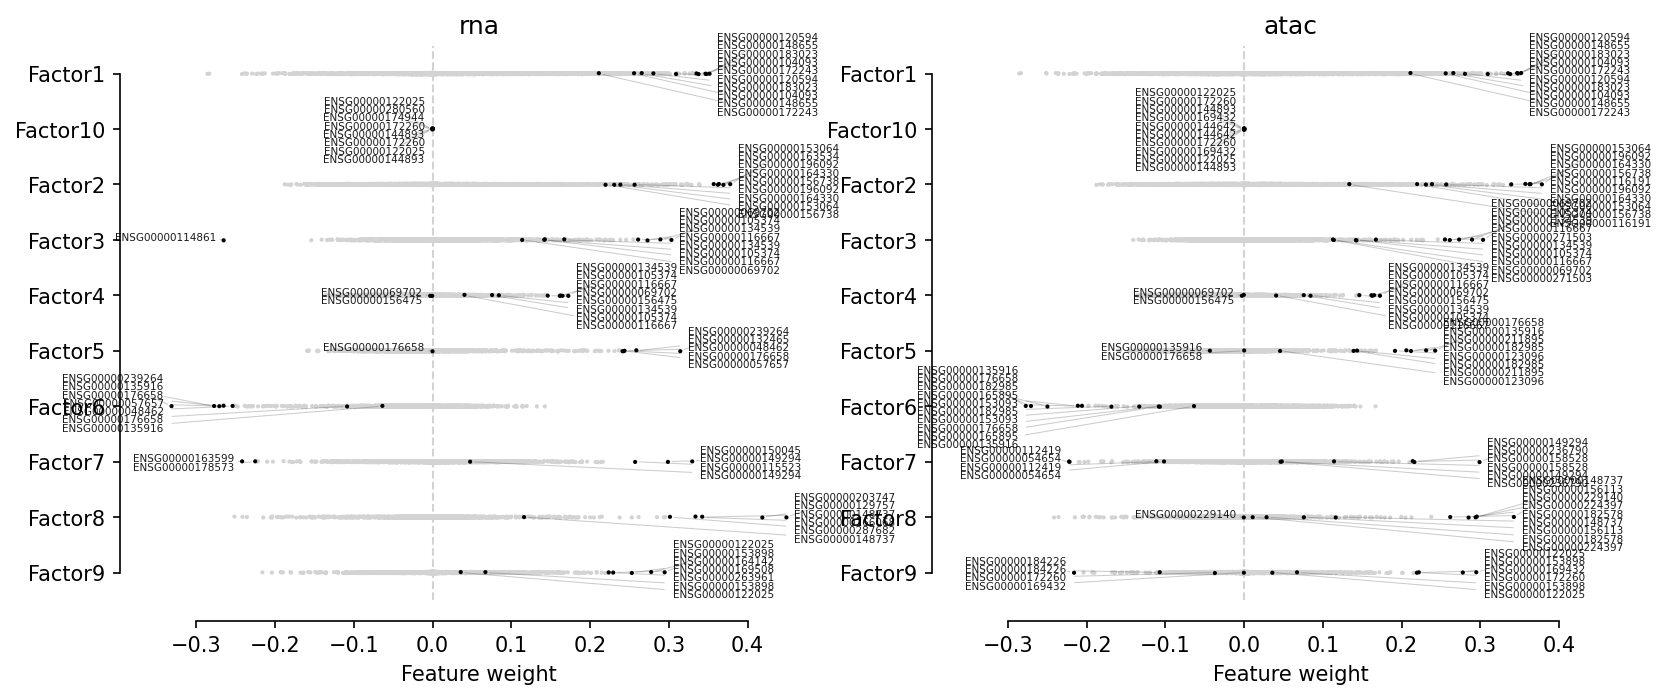

In [117]:
ax = mfx.plot_weights(cc0022_pre, n_features=5)

/home/erdem/Dropbox/projects/multiOmics/infantCOVID/.venv/lib/python3.12/site-packages/mofax/plot_weights.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna({"to_label": False})


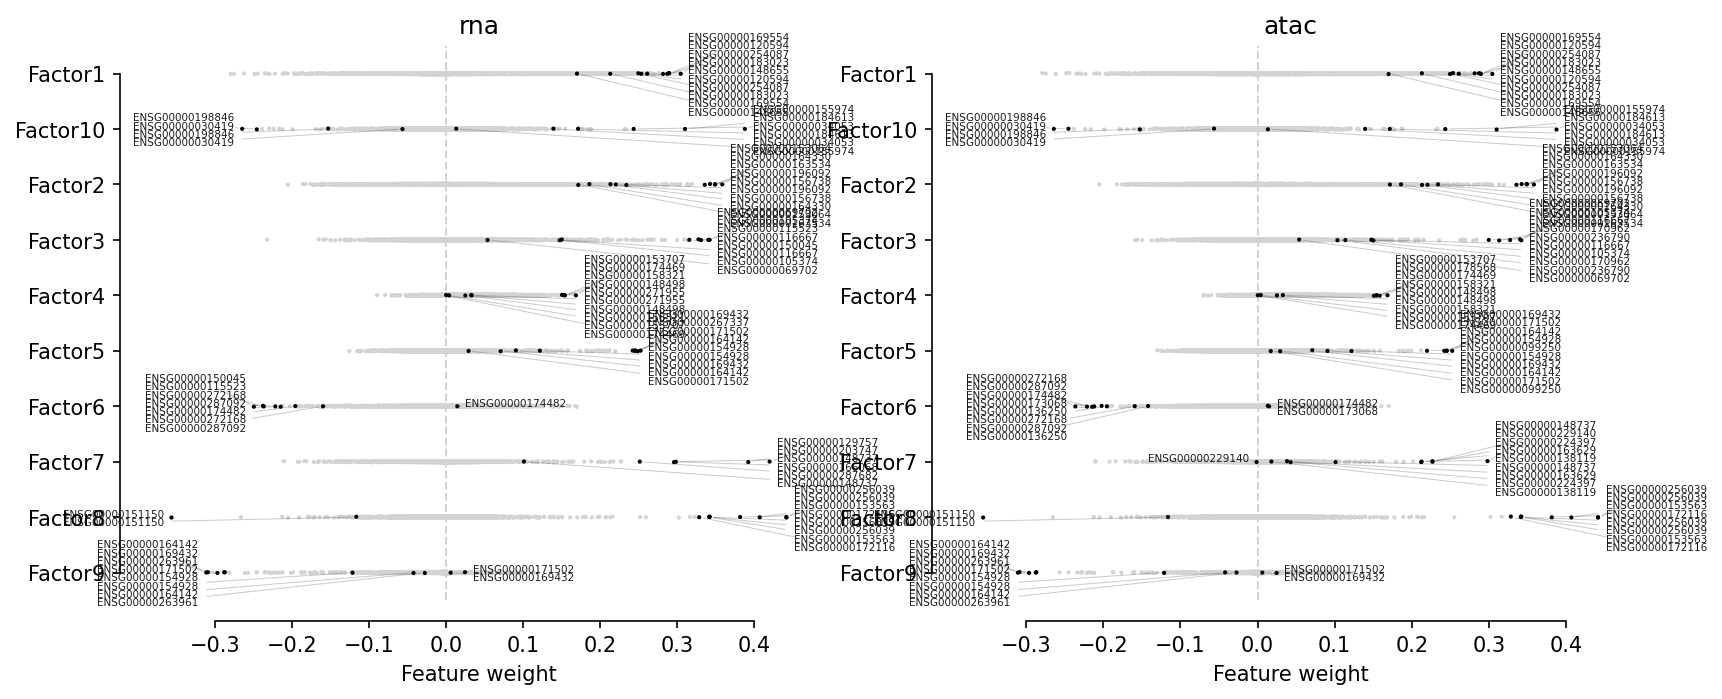

In [118]:
ax = mfx.plot_weights(cc0022_acute, n_features=5)

/home/erdem/Dropbox/projects/multiOmics/infantCOVID/.venv/lib/python3.12/site-packages/mofax/plot_weights.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna({"to_label": False})


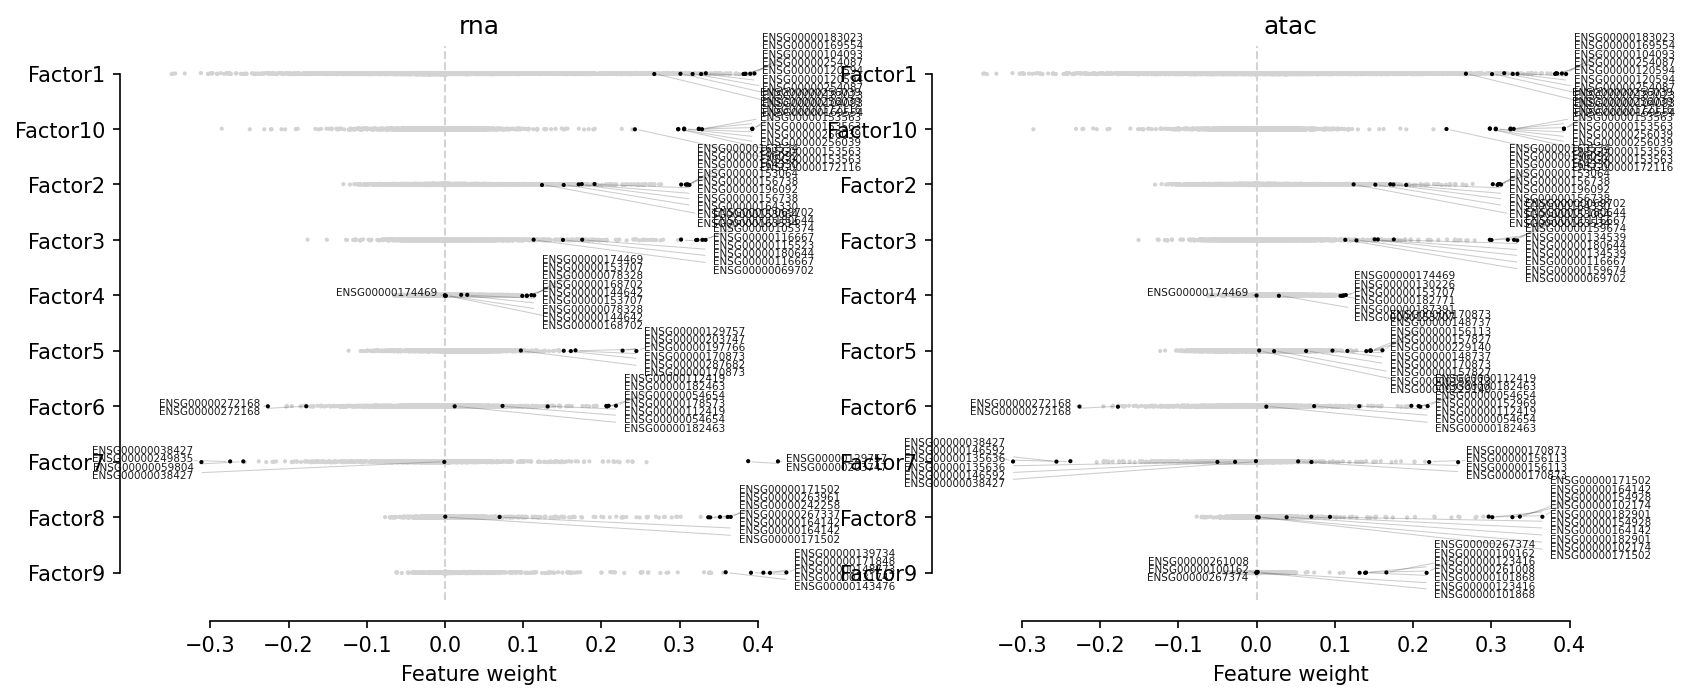

In [119]:
ax = mfx.plot_weights(cc0022_conv, n_features=5)

## Top 5 genes per factor

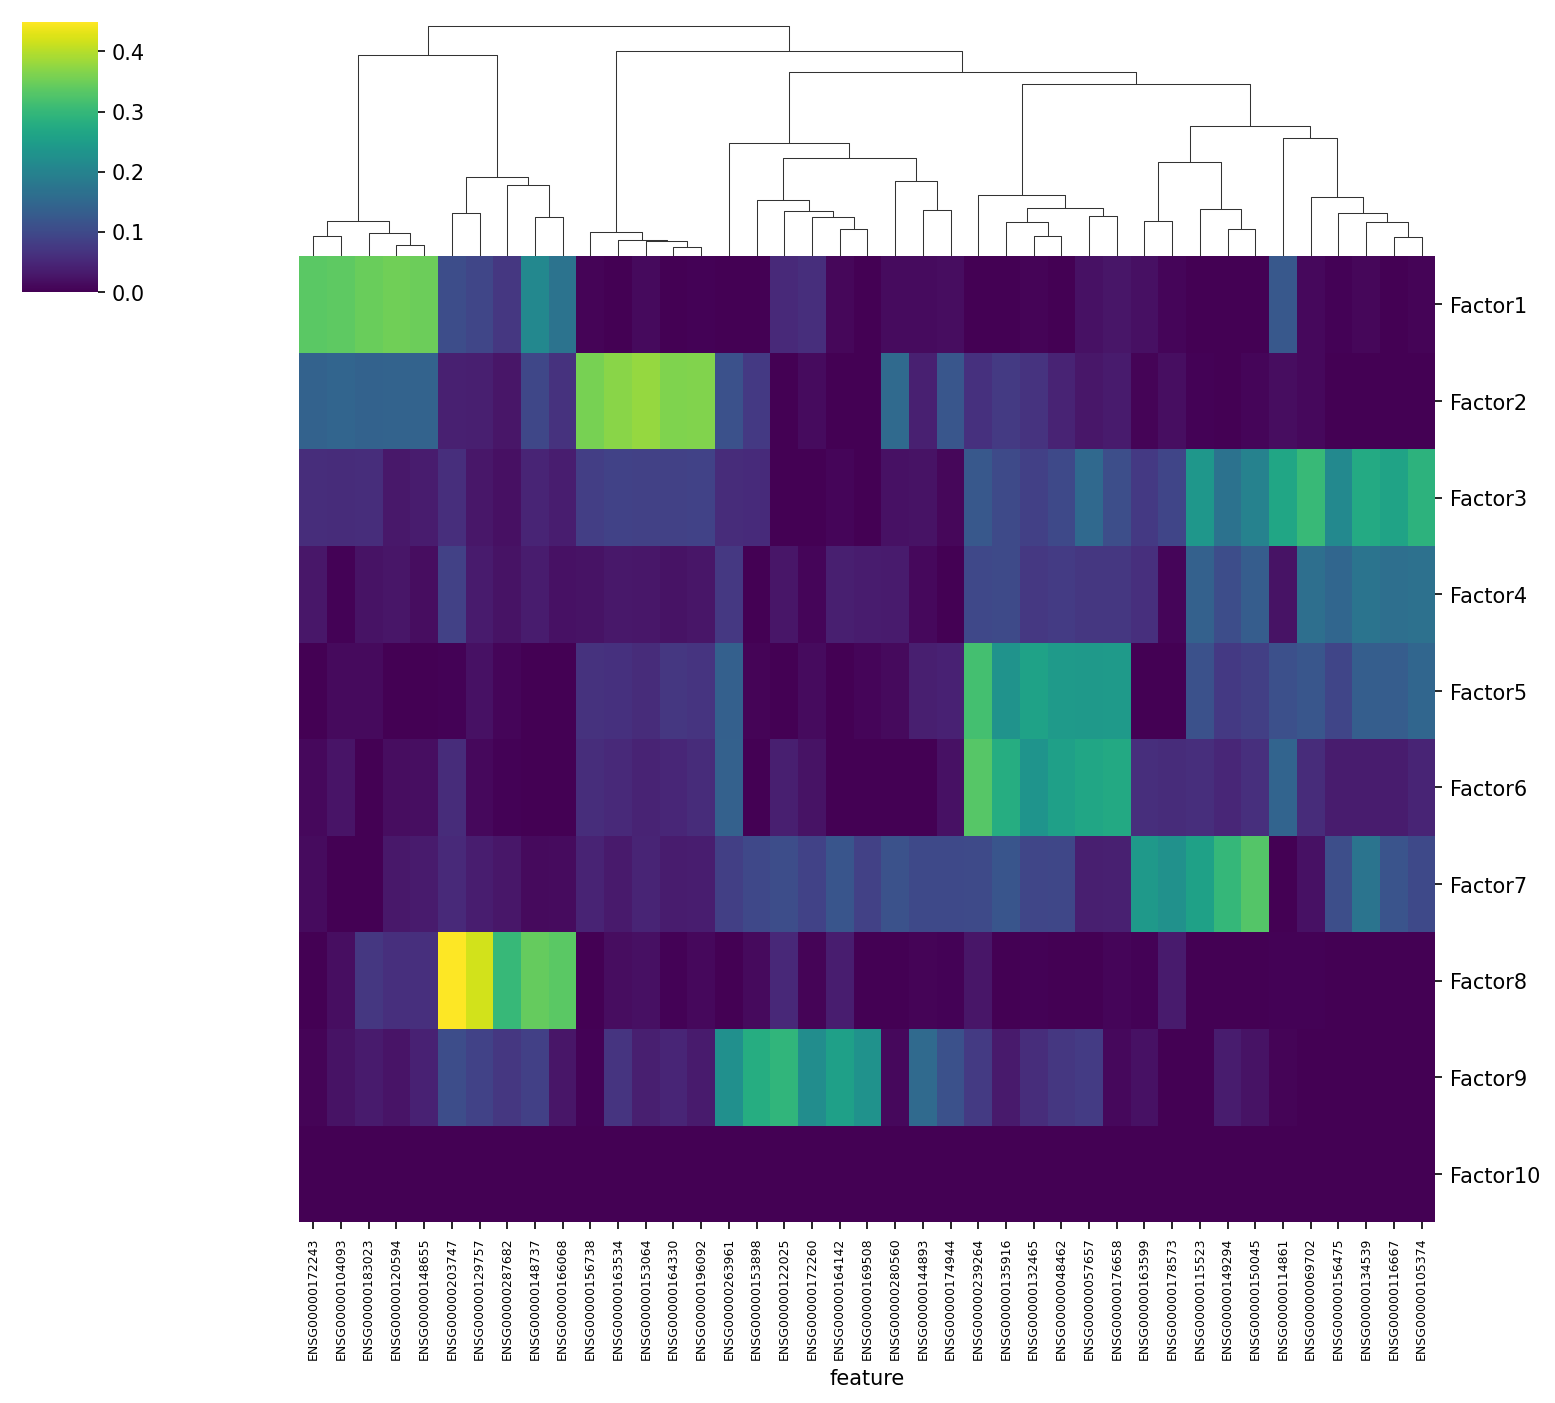

In [114]:
mfx.plot_weights_heatmap(cc0022_pre, n_features=5, 
                         factors=range(0, 10), 
                         xticklabels_size=6, w_abs=True, 
                         cmap="viridis", cluster_factors=False)

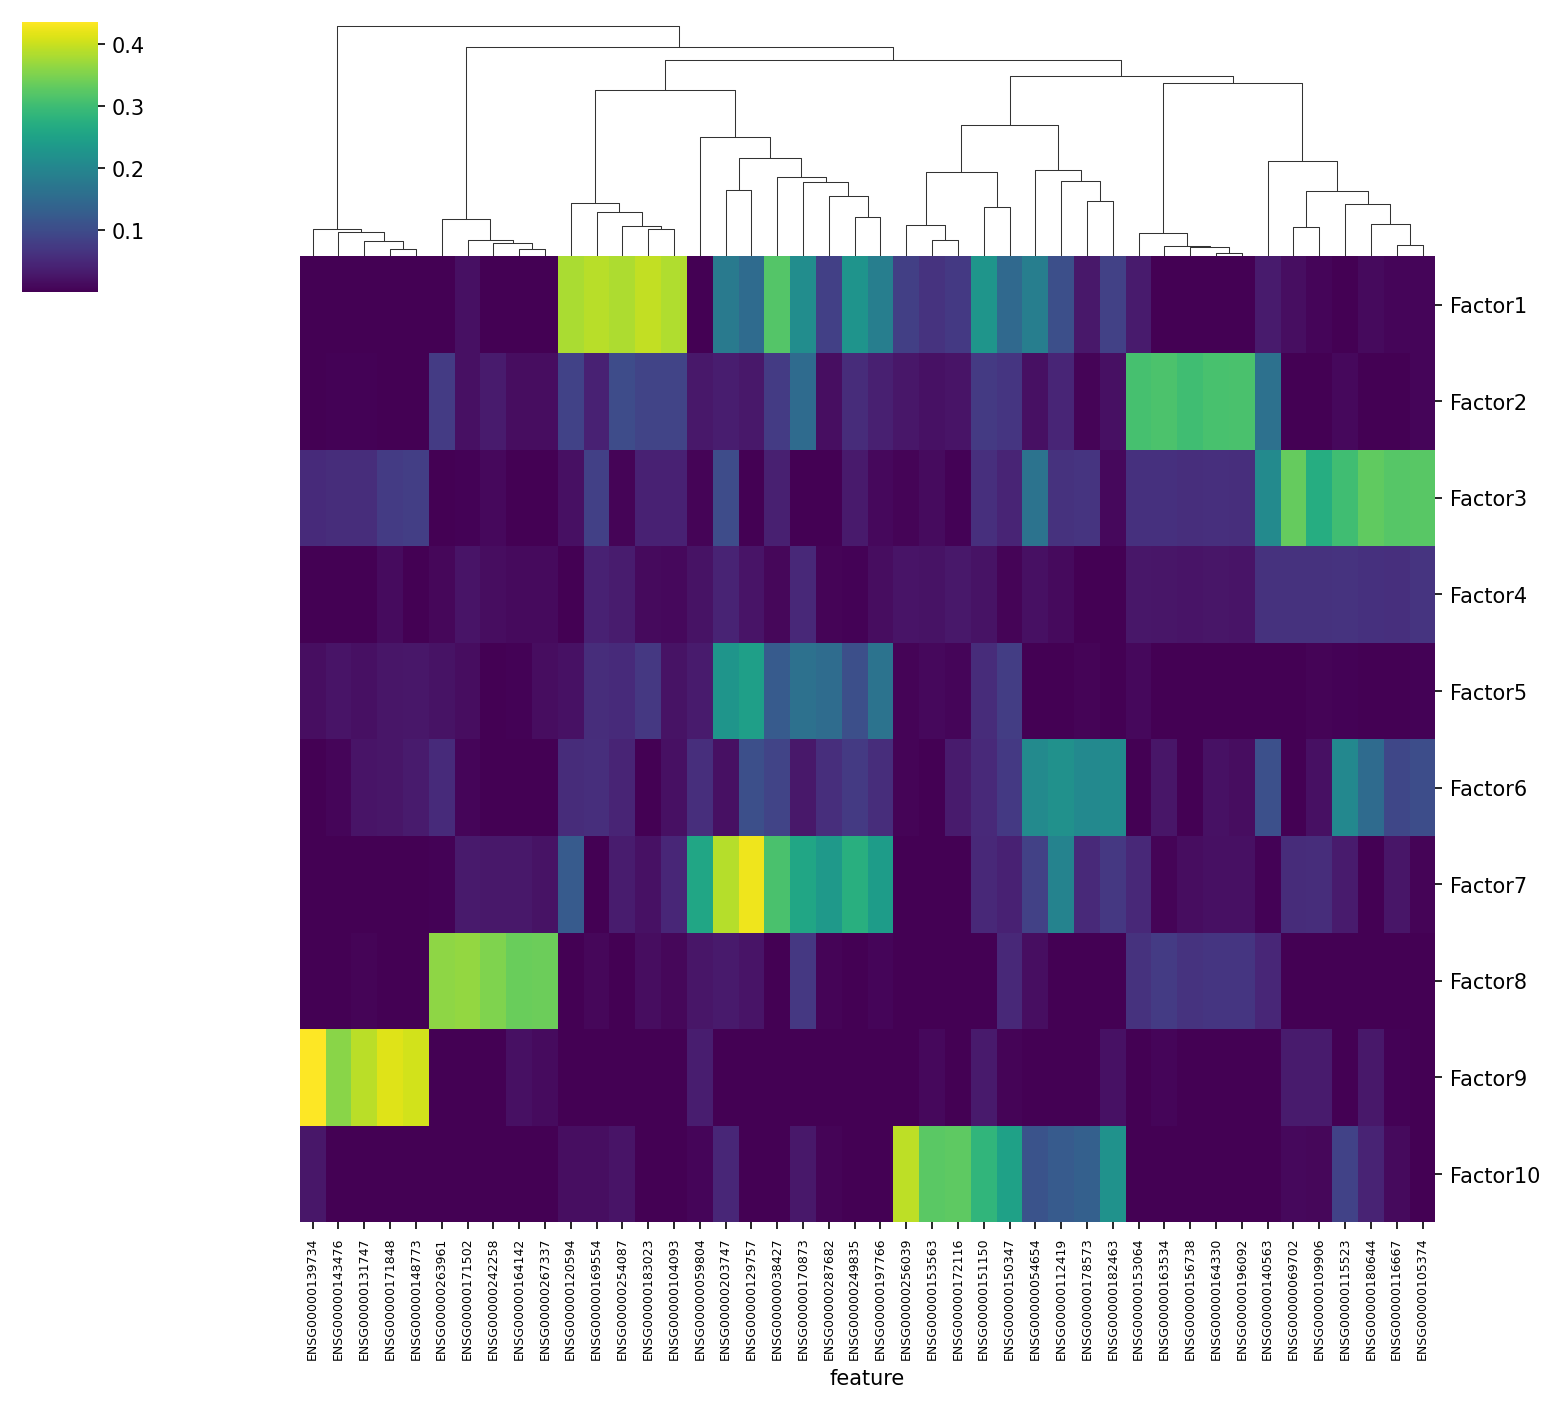

In [121]:
mfx.plot_weights_heatmap(cc0022_conv, n_features=5, 
                         factors=range(0, 10), 
                         xticklabels_size=6, w_abs=True, 
                         cmap="viridis", cluster_factors=False)

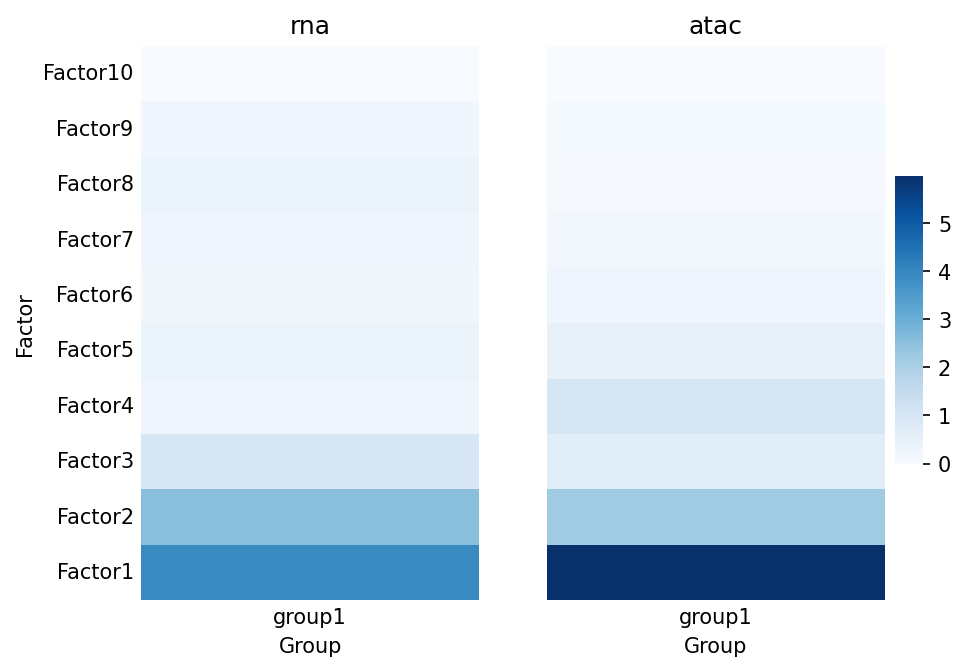

In [116]:
mfx.plot_r2(cc0022_pre, factors=list(range(10)), cmap="Blues")